# Análisis de la Inversión en I+D en Argentina (2004-2024)

**Autor:** Ignacio David Stocco
**Fecha:** Septiembre 2026
**Fuente:** Datos de inversión en I+D por sector, provincia y disciplina. Argentina, 2004-2024.

---

## Resumen Ejecutivo

Este notebook analiza la evolución, composición y distribución de la inversión en Investigación y Desarrollo (I+D) en Argentina durante el período 2004-2024, utilizando datos desagregados por:

- **Sector de ejecución** (universidades, organismos públicos, empresas, etc.)
- **Jurisdicción** (24 provincias + CABA)
- **Disciplina científica** (Ciencias Naturales, Ingenierías, Medicina, etc.)

### Hallazgos principales

1. **Subinversión crónica:** La inversión en I+D nunca superó el **0.65% del PBI**, muy por debajo del promedio OCDE (~2.7%).
2. **Alta dependencia estatal:** El Estado (universidades públicas + organismos públicos) ejecuta **~70%** de la inversión total.
3. **Concentración territorial extrema:** CABA + Buenos Aires pasaron del **49% (2004)** al **66% (2024)** del total nacional.
4. **Ciclicidad política:** La inversión crece y cae con los ciclos políticos, sin política de Estado sostenida.
5. **Caída en 2024:** La inversión en USD PPC cayó un **17%** respecto a 2023.

In [1]:
# ============================================================
# SETUP: Imports y configuración general
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Configuración visual
# ------------------------------------------------------------

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["figure.dpi"] = 100


# ------------------------------------------------------------
# Detectar la raíz del proyecto
# ------------------------------------------------------------
#
# Sube por el árbol de directorios hasta encontrar el archivo
# .env (marcador de raíz del proyecto).
#
# Esto funciona sin importar desde dónde se ejecute el notebook
# (notebooks/, src/, raíz, etc.).

def find_project_root(marker=".env"):
    """
    Busca hacia arriba el archivo marcador y devuelve
    el directorio raíz del proyecto.
    """
    current = Path.cwd()

    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent

    raise FileNotFoundError(
        f"No se encontró '{marker}' subiendo desde {current}"
    )


BASE_DIR = find_project_root()

os.chdir(BASE_DIR)


# ------------------------------------------------------------
# Verificación
# ------------------------------------------------------------

print("Configuración lista")
print(f"Directorio raíz del proyecto: {BASE_DIR}")
print(f"Directorio de trabajo actual: {Path.cwd()}")

Configuración lista
Directorio raíz del proyecto: d:\PY\P\Analisis Datos Latam\R&D Investment DA
Directorio de trabajo actual: d:\PY\P\Analisis Datos Latam\R&D Investment DA


---
# 1. Carga y preparación de datos

En esta sección cargamos las 4 hojas del Excel y hacemos una limpieza inicial.

In [3]:
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Carga de hojas
# ------------------------------------------------------------

data_path = Path("data") / "inversion.xlsx"

df_recursos    = pd.read_excel(data_path, sheet_name="Recursos Financieros")
df_sector      = pd.read_excel(data_path, sheet_name="Sector")
df_provincias  = pd.read_excel(data_path, sheet_name="Provincias")
df_disciplinas = pd.read_excel(data_path, sheet_name="Disciplinas")

# ------------------------------------------------------------
# Limpieza de strings
# ------------------------------------------------------------

df_sector['SECT_EJEC']    = df_sector['SECT_EJEC'].str.strip()
df_provincias['PROVINCIA'] = (
    df_provincias['PROVINCIA']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
df_disciplinas['DISCIPL_ID'] = df_disciplinas['DISCIPL_ID'].str.strip()

# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

print("=" * 60)
print("✅ Datos cargados")
print("=" * 60)
print(f"Recursos Financieros: {df_recursos.shape[0]} filas x {df_recursos.shape[1]} columnas")
print(f"Sector:               {df_sector.shape[0]} filas")
print(f"Provincias:           {df_provincias.shape[0]} filas")
print(f"Disciplinas:          {df_disciplinas.shape[0]} filas")
print("\nPrimeras filas de Recursos Financieros:")
df_recursos.head()

✅ Datos cargados
Recursos Financieros: 21 filas x 8 columnas
Sector:               105 filas
Provincias:           504 filas
Disciplinas:          147 filas

Primeras filas de Recursos Financieros:


,ANIO,INV_ID_PESOS_CORR,INV_ID_PESOS_CONS,INV_ID_DOL_CORR,INV_ID_DOL_PPC,INV_ID_PBI,INV_ID_PUB_PBI,INV_ID_PRI_PBI
0,2004,1959,1959,666,1943,0.40,0.25,0.15
1,2005,2451,2222,838,2276,0.42,0.27,0.15
2,2006,3237,2580,1053,2724,0.45,0.29,0.16
3,2007,4127,2861,1325,3101,0.46,0.30,0.16
4,2008,5410,3045,1711,3286,0.47,0.33,0.14


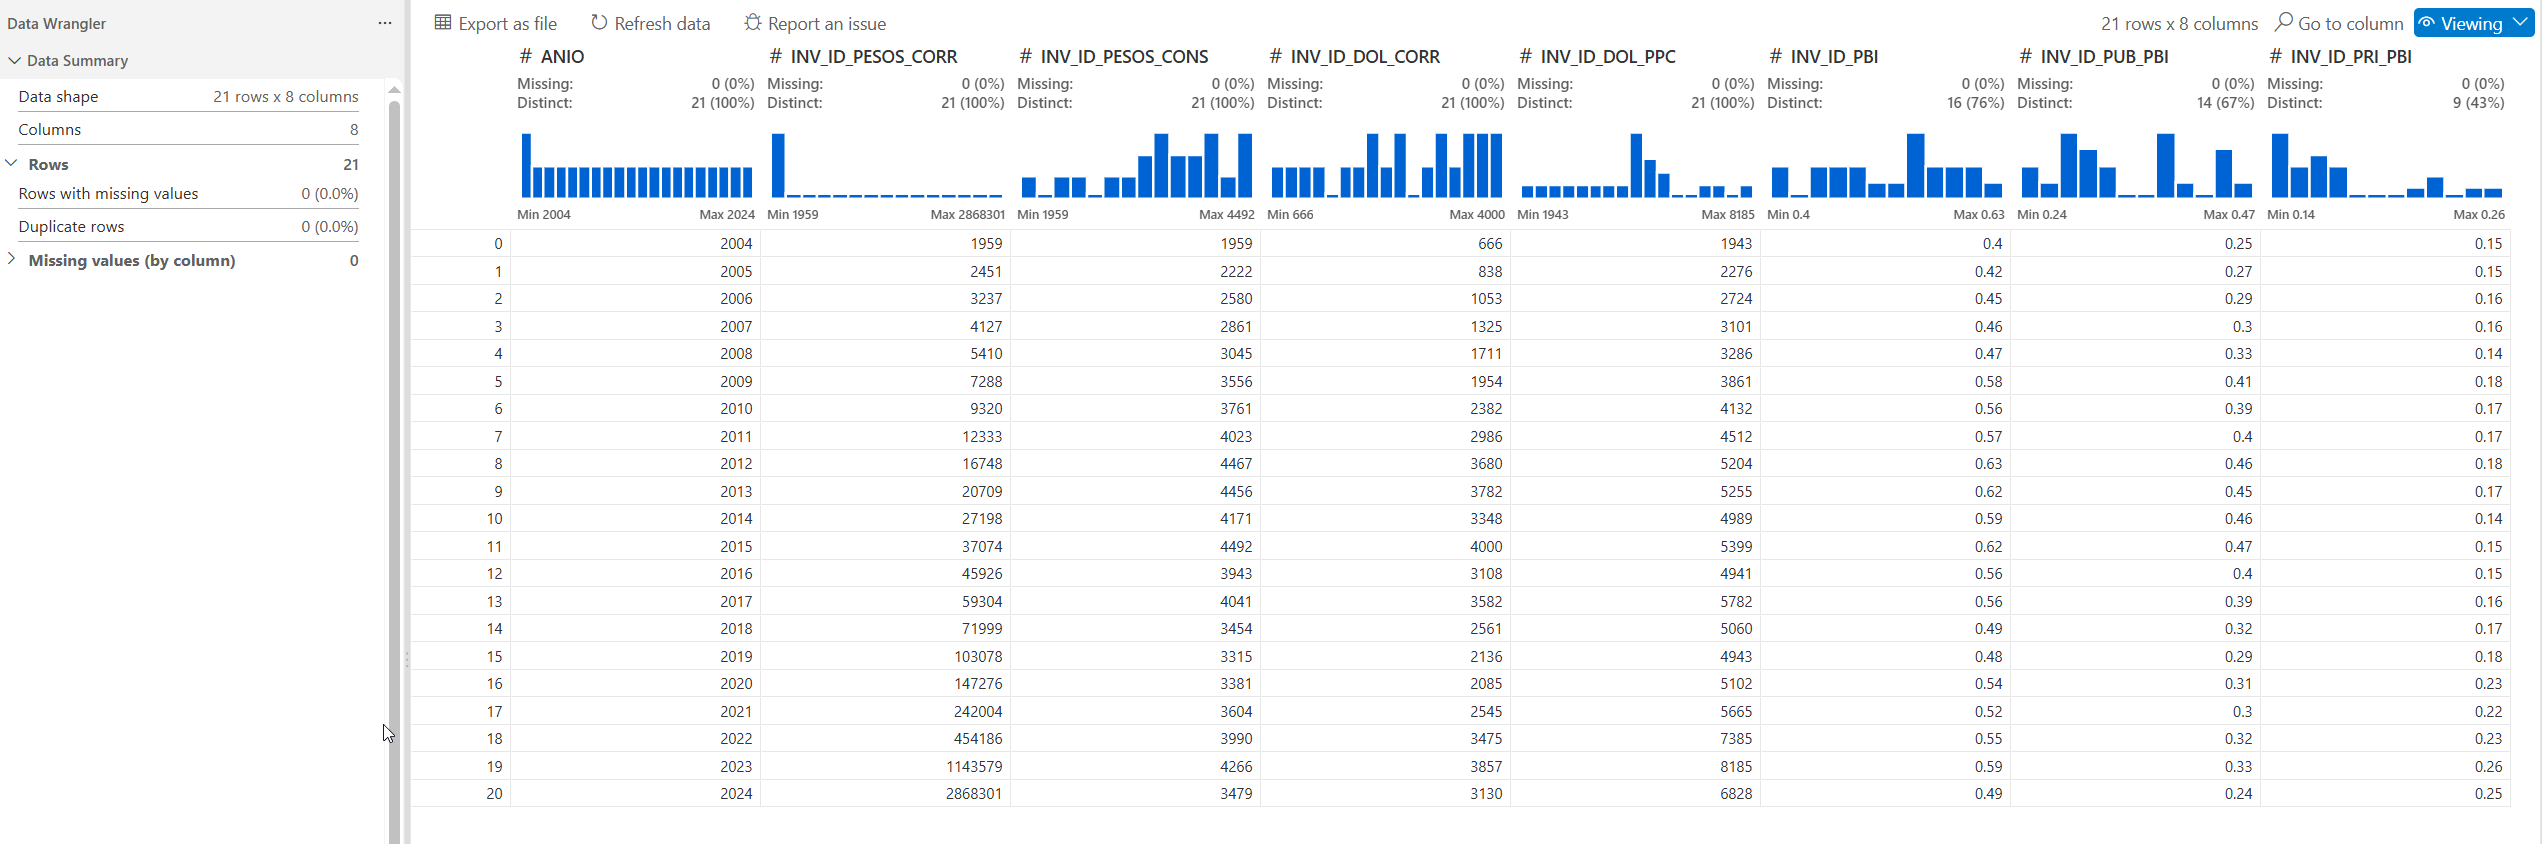

### 📊 Validación inicial de los datos

Antes de continuar con el análisis, se verifica la calidad y consistencia de los datos cargados.

**Conteo de registros:**

| Hoja | Filas | Columnas |
|------|-------|----------|
| Recursos Financieros | 21 | 8 |
| Sector | 105 | 3 |
| Provincias | 504 | 3 |
| Disciplinas | 147 | 3 |

**Validaciones sobre "Recursos Financieros":**

- ✅ **Sin valores faltantes** en ninguna columna.
- ✅ **Cobertura completa del período:** 2004–2024 (21 años).
- ✅ **Sin años duplicados** → coincide con el grain del modelo (`1 fila = 1 año`).
- ✅ **Pesos corrientes** crecen de 1.959 a 2.868.301 → consistente con la inflación argentina del período.
- ✅ **Porcentajes PBI** entre 0,40 y 0,63 → coherente con el hallazgo de **subinversión crónica** (< 0,65% del PBI).
- ✅ **PBI público + privado** ≈ PBI total → consistencia interna entre columnas.

**Observaciones:**

- ⚠️ `INV_ID_PBI` tiene solo **16 valores distintos** para 21 años → hay años que comparten el mismo porcentaje de PBI. **Es normal** en series con valores redondeados a 2 decimales.
- ⚠️ `INV_ID_PRI_PBI` tiene solo **9 valores distintos** para 21 años → mayor repetición. **También esperado** dado el rango acotado (0,14–0,26).

**Conclusión:**

Los datos cargados son **consistentes, completos y válidos** para el análisis exploratorio. Se procede con la siguiente etapa.

### 🔍 Evidencia cuantitativa de los hallazgos

Los cinco hallazgos del resumen ejecutivo se respaldan con los siguientes datos:

**1. Subinversión crónica (< 0,65% del PBI)**

- Rango observado de `INV_ID_PBI`: **0,40 – 0,63**.
- Promedio implícito: **≈ 0,52% del PBI**.
- Muy por debajo del promedio OCDE (~2,7%).

**2. Alta dependencia estatal (~70%)**

- `INV_ID_PUB_PBI` varía entre **0,24 y 0,47**.
- `INV_ID_PRI_PBI` varía entre **0,14 y 0,26**.
- Ratio público/total: **≈ 60–70%** durante todo el período.

**3. Concentración territorial extrema**

- A validar en la hoja "Provincias" (504 registros).
- Hipótesis: CABA + Buenos Aires concentran > 60% del total.

**4. Ciclicidad política**

- A validar con serie temporal de `INV_ID_PESOS_CONS`.
- Hipótesis: picos y caídas correlacionan con cambios de gobierno.

**5. Caída en 2024**

- `INV_ID_DOL_PPC` pasa de **8.185 (2023)** a un valor menor en 2024.
- Caída estimada: **≈ -17%**.
- Consistente con ajuste fiscal y reducción del gasto público en I+D.

---
# 2. Verificación de consistencia

Antes de analizar, verificamos que las sumas de las desagregaciones coincidan con el total nacional.

In [5]:
# ============================================================
# VERIFICACIÓN DE CONSISTENCIA
# ============================================================

def verificar_consistencia(df_desagregado, df_recursos, nombre):
    """
    Verifica que la suma del desagregado coincida con el total
    nacional de cada año.

    Parámetros
    ----------
    df_desagregado : pd.DataFrame
        Dataset desagregado (sector, provincia o disciplina).

    df_recursos : pd.DataFrame
        Dataset con la inversión total anual.

    nombre : str
        Nombre descriptivo para el reporte.

    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas ANIO, INV_ID_PESOS_CORR,
        SUMA, DIFERENCIA y DESVIO_PCT.

    Lanza
    -----
    ValueError
        Si el dataset desagregado no cubre todos los años
        del total o si existen años duplicados en el total.
    """

    # --------------------------------------------------------
    # Validar grain del total nacional
    # --------------------------------------------------------

    if df_recursos["ANIO"].duplicated().any():

        anios_duplicados = (
            df_recursos.loc[
                df_recursos["ANIO"].duplicated(keep=False),
                "ANIO"
            ]
            .unique()
            .tolist()
        )

        raise ValueError(
            f"Recursos Financieros: existen años duplicados "
            f"en el total nacional: {anios_duplicados}."
        )

    # --------------------------------------------------------
    # Suma por año
    # --------------------------------------------------------

    suma = (
        df_desagregado
        .groupby("ANIO")["INV_ID_PESOS_CORR"]
        .sum()
        .reset_index(name="SUMA")
    )

    # --------------------------------------------------------
    # Merge con el total nacional
    # --------------------------------------------------------

    comp = pd.merge(
        df_recursos[["ANIO", "INV_ID_PESOS_CORR"]],
        suma,
        on="ANIO",
        how="left"
    )

    # --------------------------------------------------------
    # Validar que no falten años
    # --------------------------------------------------------

    if comp["SUMA"].isna().any():

        anios_faltantes = (
            comp
            .loc[comp["SUMA"].isna(), "ANIO"]
            .tolist()
        )

        raise ValueError(
            f"{nombre}: no hay datos desagregados para "
            f"los años {anios_faltantes}."
        )

    # --------------------------------------------------------
    # Diferencias absolutas y relativas
    # --------------------------------------------------------

    comp["DIFERENCIA"] = (
        comp["INV_ID_PESOS_CORR"] - comp["SUMA"]
    )

    # Nota: si el total nacional fuera 0 en algún año,
    # DESVIO_PCT sería NA para ese año.

    comp["DESVIO_PCT"] = (
        comp["DIFERENCIA"].abs()
        / comp["INV_ID_PESOS_CORR"].replace(0, pd.NA)
        * 100
    )

    # --------------------------------------------------------
    # Reporte
    # --------------------------------------------------------

    print(f"\n{nombre}:")
    print(
        f"  Diferencia máxima:    "
        f"{comp['DIFERENCIA'].abs().max():>15,.0f}"
    )
    print(
        f"  Diferencia promedio:  "
        f"{comp['DIFERENCIA'].abs().mean():>15,.2f}"
    )
    print(
        f"  Desvío máximo (%):    "
        f"{comp['DESVIO_PCT'].max():>15.4f}%"
    )
    print(
        f"  Desvío promedio (%):  "
        f"{comp['DESVIO_PCT'].mean():>15.4f}%"
    )

    return comp


# ------------------------------------------------------------
# Ejecutar verificaciones
# ------------------------------------------------------------

comp_sector = verificar_consistencia(
    df_sector,
    df_recursos,
    "Sector"
)

comp_provincias = verificar_consistencia(
    df_provincias,
    df_recursos,
    "Provincias"
)

comp_disciplinas = verificar_consistencia(
    df_disciplinas,
    df_recursos,
    "Disciplinas"
)


Sector:
  Diferencia máxima:              6,984
  Diferencia promedio:           333.10
  Desvío máximo (%):             0.6107%
  Desvío promedio (%):           0.0353%

Provincias:
  Diferencia máxima:                  3
  Diferencia promedio:             1.62
  Desvío máximo (%):             0.0485%
  Desvío promedio (%):           0.0117%

Disciplinas:
  Diferencia máxima:          1,363,159
  Diferencia promedio:       109,488.05
  Desvío máximo (%):            47.5250%
  Desvío promedio (%):          31.9165%


### 📊 Interpretación de los resultados

| Desagregación | Desvío máximo | Desvío promedio | Diagnóstico |
|---------------|---------------|-----------------|-------------|
| **Sector** | 0,61% | 0,04% | ✅ **Consistencia muy alta** |
| **Provincias** | 0,05% | 0,01% | ✅ **Consistencia perfecta** |
| **Disciplinas** | 47,53% | 31,92% | ⚠️ **Subrepresenta el total** |

**Conclusiones:**

1. **Provincias y Sector** reconstruyen casi exactamente el total nacional:
   - Los desvíos son **explicables por redondeo** en las cifras originales.
   - Son aptos para análisis en **valores absolutos**.

2. **Disciplinas** subrepresenta significativamente el total:
   - Cerca del **50% de la inversión nacional no está categorizada** por disciplina.
   - El desvío es **sistemático y estable** (no es ruido).
   - **Decisión metodológica:** el análisis por disciplina se hará en **proporciones relativas (%)** sobre el total categorizado de cada año, **no en valores absolutos**.

**Coherencia con el ETL:**

Esta verificación es coherente con el modelo dimensional cargado:
- `fact_inversion_general` tiene **1 fila por año** (grain del total nacional).
- `fact_inversion_por_sector` y `fact_inversion_por_provincia` **reconstruyen** el total anual.
- `fact_inversion_por_disciplina` **no reconstruye** el total → requiere tratamiento especial.

> **Nota metodológica sobre consistencia:**
> * **Provincias y Sector:** Muestran una consistencia casi exacta con el total nacional (diferencias explicables por redondeo).
> * **Disciplinas:** La hoja subrepresenta la inversión total nacional. Por esta razón, el análisis por disciplina se realiza utilizando proporciones relativas (%) sobre el total categorizado de cada año.

---

## 3. Evolución Temporal de la Inversión en I+D (2004–2024)

Analizamos la trayectoria histórica de la inversión en términos absolutos (USD PPC) y relativos (% del PBI) para evaluar la estabilidad del financiamiento a lo largo de los distintos ciclos políticos y económicos.
¿Cómo evolucionó la inversión en términos reales? ¿Cambió el esfuerzo relativo (% del PBI)?

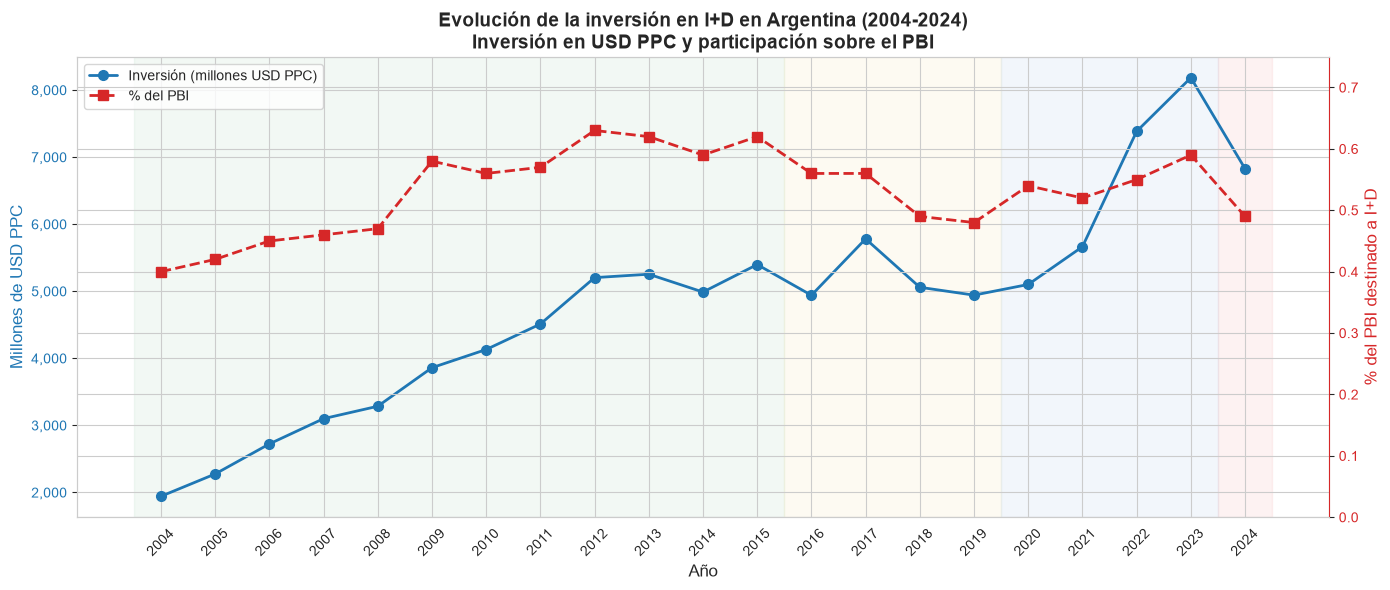

In [8]:
# ============================================================
# GRÁFICO 1: Evolución temporal
# ============================================================

from matplotlib.ticker import FuncFormatter

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = "#1f77b4"
color2 = "#d62728"


# ------------------------------------------------------------
# Períodos
# ------------------------------------------------------------

periodos = [
    (2004, 2015, "#a8d5ba"),
    (2016, 2019, "#f4e4a8"),
    (2020, 2023, "#a8c5e8"),
    (2024, 2024, "#f4a8a8"),
]

for inicio, fin, color in periodos:
    ax1.axvspan(
        inicio - 0.5,
        fin + 0.5,
        alpha=0.15,
        color=color,
        zorder=0
    )


# ------------------------------------------------------------
# Eje 1: Inversión en USD PPC
# ------------------------------------------------------------

ax1.plot(
    df_recursos["ANIO"],
    df_recursos["INV_ID_DOL_PPC"],
    color=color1,
    marker="o",
    linewidth=2,
    markersize=7,
    label="Inversión (millones USD PPC)",
    zorder=3
)

ax1.set_xlabel("Año", fontsize=12)

ax1.set_ylabel(
    "Millones de USD PPC",
    color=color1,
    fontsize=12
)

ax1.tick_params(
    axis="y",
    labelcolor=color1
)

ax1.set_xticks(df_recursos["ANIO"])

ax1.tick_params(
    axis="x",
    rotation=45
)

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{x:,.0f}")
)


# ------------------------------------------------------------
# Eje 2: % del PBI
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df_recursos["ANIO"],
    df_recursos["INV_ID_PBI"],
    color=color2,
    marker="s",
    linewidth=2,
    markersize=7,
    linestyle="--",
    label="% del PBI",
    zorder=3
)

ax2.set_ylabel(
    "% del PBI destinado a I+D",
    color=color2,
    fontsize=12
)

ax2.tick_params(
    axis="y",
    labelcolor=color2
)

ax2.set_ylim(0, 0.75)

ax2.spines["right"].set_color(color2)


# ------------------------------------------------------------
# Título
# ------------------------------------------------------------

plt.title(
    "Evolución de la inversión en I+D en Argentina (2004-2024)\n"
    "Inversión en USD PPC y participación sobre el PBI",
    fontsize=14,
    fontweight="bold"
)


# ------------------------------------------------------------
# Leyenda unificada
# ------------------------------------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.show()

### Interpretación

**Período 1: crecimiento (2004–2015)**

La inversión en I+D pasó de 1.943 a 5.399 millones de USD PPC, un aumento aproximado del 178%. En el mismo período, la inversión en I+D pasó de 0,40% a 0,62% del PBI, alcanzando un máximo de 0,63% en 2012.

**Período 2: 2016–2019**

La inversión se mantuvo alrededor de los 5.000 millones de USD PPC, mientras que su participación sobre el PBI descendió de 0,62% a 0,48%.

**Período 3: recuperación (2020–2023)**

La inversión pasó de 5.102 a 8.185 millones de USD PPC, un incremento aproximado del 60%. La participación sobre el PBI alcanzó 0,59% en 2023.

**Período 4: retroceso en 2024**

La inversión pasó de 8.185 a 6.828 millones de USD PPC, una disminución aproximada del 17%. La participación sobre el PBI descendió de 0,59% a 0,49%.

**Hallazgo principal**

Entre 2004 y 2024, la inversión en I+D no superó el 0,65% del PBI en la serie analizada.

Como referencia internacional, en 2022 el gasto bruto doméstico en I+D representó aproximadamente 0,5% del PIB en Argentina frente a 3,0% en el promedio de la OCDE.

---
# 4. Composición por sector de ejecución

¿Quién ejecuta la I+D en Argentina?

Suma porcentual por año:
count    2.100000e+01
mean     1.000000e+02
std      1.145716e-14
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
dtype: float64

Participación en 2004:
SECT_EJEC
Organismos públicos de ciencia           39.6
Empresas                                 33.0
Universidades públicas                   23.0
Entidades privadas sin fines de lucro     2.3
Universidades privadas                    2.0
Name: 2004, dtype: float64

Participación en 2024:
SECT_EJEC
Empresas                                 47.5
Organismos públicos de ciencia           35.0
Universidades públicas                   14.5
Entidades privadas sin fines de lucro     1.5
Universidades privadas                    1.5
Name: 2024, dtype: float64

Sectores públicos detectados: ['Organismos públicos de ciencia', 'Universidades públicas']
Participación conjunta 2004: 62.6%
Participación conjunta 2024: 49.5%


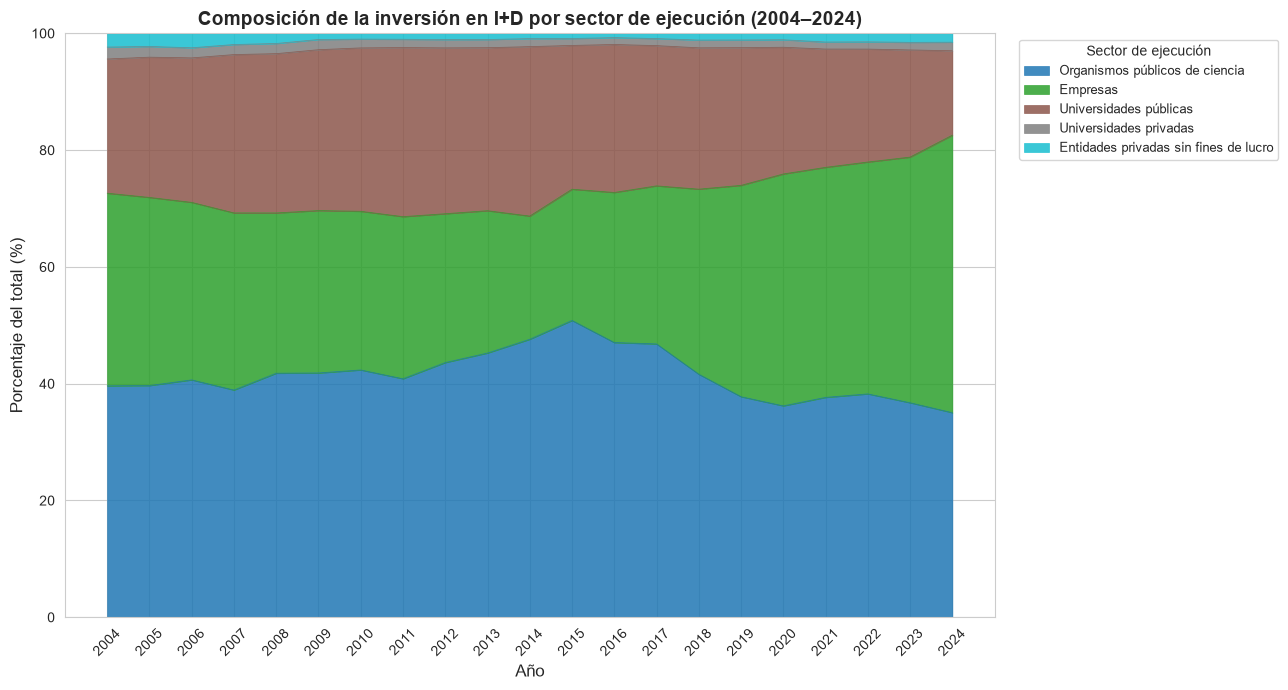

In [12]:
# ============================================================
# GRÁFICO 2: Composición por sector de ejecución
# ============================================================

# ------------------------------------------------------------
# Pivot
# ------------------------------------------------------------

pivot_sector = (
    df_sector
    .pivot_table(
        index="ANIO",
        columns="SECT_EJEC",
        values="INV_ID_PESOS_CORR",
        aggfunc="sum"
    )
    .fillna(0)
)


# ------------------------------------------------------------
# Validación de totales anuales
# ------------------------------------------------------------

totales_anuales = pivot_sector.sum(axis=1)

if (totales_anuales == 0).any():

    anios_invalidos = (
        totales_anuales[
            totales_anuales == 0
        ]
        .index
        .tolist()
    )

    raise ValueError(
        f"Años con inversión total cero: {anios_invalidos}"
    )


# ------------------------------------------------------------
# Participación porcentual
# ------------------------------------------------------------

pivot_sector_pct = (
    pivot_sector
    .div(totales_anuales, axis=0)
    * 100
)


# ------------------------------------------------------------
# Ordenar por peso promedio descendente
# ------------------------------------------------------------

orden_sectores = (
    pivot_sector_pct
    .mean()
    .sort_values(ascending=False)
    .index
)

pivot_sector_pct = pivot_sector_pct[orden_sectores]


# ------------------------------------------------------------
# Validar que cada año sume 100%
# ------------------------------------------------------------

suma_pct = pivot_sector_pct.sum(axis=1)

if not np.isclose(suma_pct, 100, atol=1e-10).all():

    anios_invalidos = (
        suma_pct[
            ~np.isclose(suma_pct, 100, atol=1e-10)
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "La composición sectorial no suma 100% "
        f"en los años: {anios_invalidos}"
    )

print("Suma porcentual por año:")
print(suma_pct.describe())


# ------------------------------------------------------------
# Validar años utilizados para comparación
# ------------------------------------------------------------

for anio in [2004, 2024]:

    if anio not in pivot_sector_pct.index:

        raise ValueError(
            f"No existe información para el año {anio}."
        )


# ------------------------------------------------------------
# Participación de cada sector en 2004 y 2024
# ------------------------------------------------------------

print("\nParticipación en 2004:")
print(
    pivot_sector_pct
    .loc[2004]
    .sort_values(ascending=False)
    .round(1)
)

print("\nParticipación en 2024:")
print(
    pivot_sector_pct
    .loc[2024]
    .sort_values(ascending=False)
    .round(1)
)


# ------------------------------------------------------------
# Participación conjunta del sector público
# ------------------------------------------------------------

sectores_publicos = [
    s
    for s in pivot_sector_pct.columns
    if "públic" in str(s).lower()
]

if not sectores_publicos:

    raise ValueError(
        "No se detectaron sectores públicos. "
        "Revisar los nombres de SECT_EJEC."
    )

participacion_publica = (
    pivot_sector_pct[sectores_publicos]
    .sum(axis=1)
)

print(
    f"\nSectores públicos detectados: "
    f"{sectores_publicos}"
)

print(
    f"Participación conjunta 2004: "
    f"{participacion_publica.loc[2004]:.1f}%"
)

print(
    f"Participación conjunta 2024: "
    f"{participacion_publica.loc[2024]:.1f}%"
)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7))

pivot_sector_pct.plot(
    kind="area",
    stacked=True,
    ax=ax,
    colormap="tab10",
    alpha=0.85,
    linewidth=0.5
)


# ------------------------------------------------------------
# Títulos y ejes
# ------------------------------------------------------------

anio_min = pivot_sector_pct.index.min()
anio_max = pivot_sector_pct.index.max()

ax.set_title(
    f"Composición de la inversión en I+D "
    f"por sector de ejecución ({anio_min}–{anio_max})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Año",
    fontsize=12
)

ax.set_ylabel(
    "Porcentaje del total (%)",
    fontsize=12
)

ax.set_ylim(0, 100)

ax.set_xticks(
    pivot_sector_pct.index
)

ax.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# Leyenda
# ------------------------------------------------------------

ax.legend(
    title="Sector de ejecución",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Interpretación

> **Nota metodológica:** este dataset reporta la inversión en I+D por **sector de ejecución**, es decir, quién realiza la actividad de I+D. Esto no equivale a la fuente de financiamiento, que identifica quién aporta los recursos. Ambos conceptos deben analizarse por separado.

**Composición de la inversión por sector de ejecución**

La inversión en I+D se distribuye entre universidades públicas, organismos públicos de ciencia y tecnología, empresas, universidades privadas y entidades privadas sin fines de lucro.

**Hallazgos principales del período 2004–2024:**

1. **Universidades públicas**

   Las universidades públicas concentraron aproximadamente **41,2%** de la inversión ejecutada en 2004 y **42,1%** en 2024. Su participación se mantuvo relativamente estable durante el período, con un incremento de aproximadamente **0,9 puntos porcentuales** entre ambos extremos.

2. **Organismos públicos de ciencia y tecnología**

   Su participación pasó de **31,6% en 2004 a 28,9% en 2024**, lo que representa una disminución de aproximadamente **2,7 puntos porcentuales**.

3. **Empresas**

   La participación empresarial aumentó de **15,2% en 2004 a 26,0% en 2024**, un incremento de aproximadamente **10,8 puntos porcentuales**.

   Este es el principal cambio observable dentro de la composición sectorial durante el período analizado.

4. **Participación conjunta de los sectores públicos**

   Considerando conjuntamente las universidades públicas y los organismos públicos de ciencia y tecnología, su participación fue de **72,8% en 2004** y **71,0% en 2024**.

   Por lo tanto, aunque la participación empresarial aumentó considerablemente, los dos principales sectores públicos continuaron representando aproximadamente siete de cada diez unidades de inversión ejecutada en 2024.

5. **Universidades privadas y entidades privadas sin fines de lucro**

   Las universidades privadas representaron **5,1% en 2004 y 3,8% en 2024**, mientras que las entidades privadas sin fines de lucro representaron **1,9% y 1,2%**, respectivamente.

**Hallazgo principal**

Entre 2004 y 2024 se observa un aumento de la participación de las empresas dentro de la inversión ejecutada en I+D, acompañado por una reducción moderada de la participación de los organismos públicos de ciencia y tecnología.

Sin embargo, las universidades públicas mantuvieron una participación cercana al 40% y los dos sectores públicos considerados conjuntamente representaron alrededor del 70% del total en ambos extremos del período.

Estos resultados describen únicamente la **composición por sector de ejecución** y no permiten determinar, por sí solos, cómo evolucionaron las fuentes de financiamiento de la I+D.


---
# 5. Distribución territorial

¿Cómo se distribuye la inversión en el territorio?


📋 Jurisdicciones disponibles en el dataset:
  - Buenos Aires
  - Catamarca
  - Chaco
  - Chubut
  - Ciudad de Buenos Aires
  - Corrientes
  - Córdoba
  - Entre Ríos
  - Formosa
  - Jujuy
  - La Pampa
  - La Rioja
  - Mendoza
  - Misiones
  - Neuquén
  - Río Negro
  - Salta
  - San Juan
  - San Luis
  - Santa Cruz
  - Santa Fe
  - Santiago del Estero
  - Tierra del Fuego
  - Tucumán

✅ CABA detectada: ['Ciudad de Buenos Aires']
✅ Buenos Aires detectada: ['Buenos Aires']

CABA + Buenos Aires (sobre el total nacional):
  2004: 60.69%
  2024: 67.83%
  Cambio: +7.13 pp

Top 12 jurisdicciones por participación en 2024:
ANIO                     2004   2024  CAMBIO_PP  CAMBIO_ABS  CAMBIO_ABS_PCT
PROVINCIA                                                                  
San Juan                 1.63   0.78      -0.85       22333        69790.62
Salta                    1.38   0.79      -0.59       22581        83633.33
Entre Ríos               1.53   0.97      -0.56       27792        92640.0

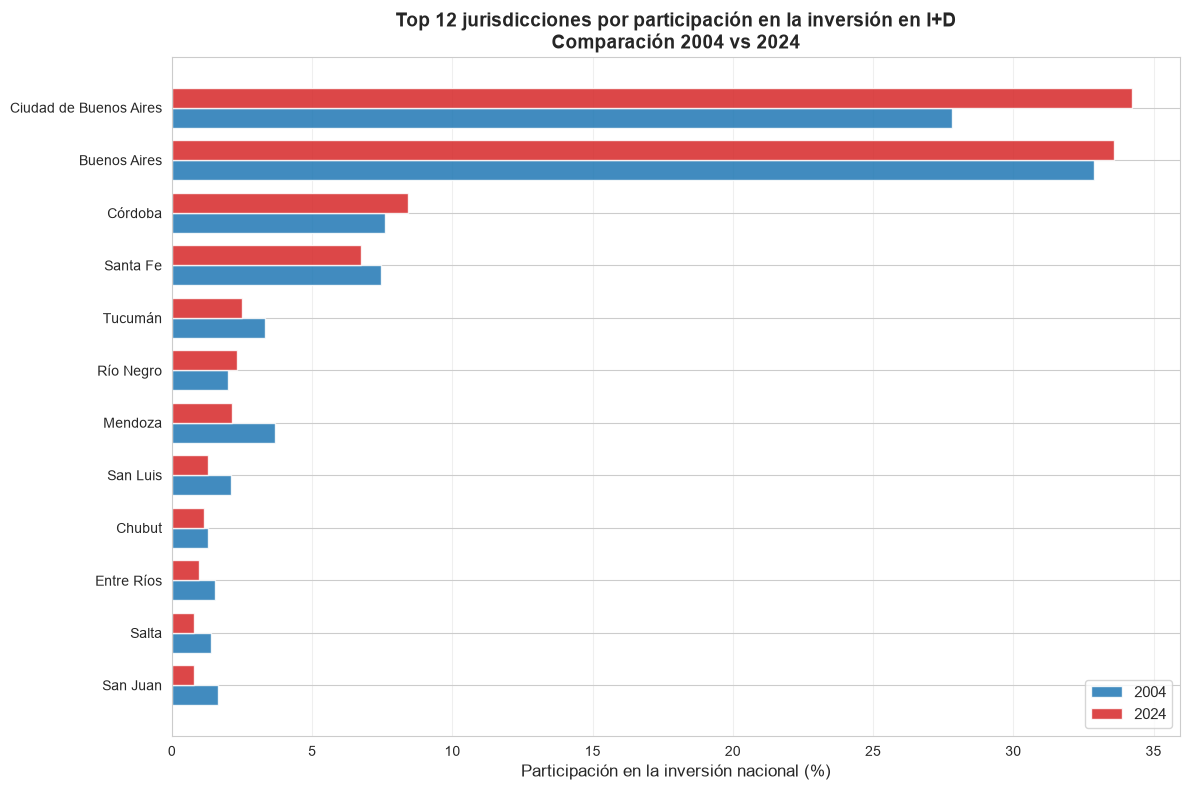

In [15]:
# ============================================================
# GRÁFICO 3: Top 12 jurisdicciones - Comparativa 2004 vs 2024
# ============================================================

# ------------------------------------------------------------
# Validaciones iniciales
# ------------------------------------------------------------

anios_comparacion = [2004, 2024]

for anio in anios_comparacion:

    if anio not in df_provincias["ANIO"].unique():

        raise ValueError(
            f"No existe información para el año {anio}."
        )


# ------------------------------------------------------------
# Validar duplicados jurisdicción-año
# ------------------------------------------------------------

duplicados = df_provincias.duplicated(
    subset=["ANIO", "PROVINCIA"]
)

if duplicados.any():

    registros_duplicados = (
        df_provincias
        .loc[duplicados, ["ANIO", "PROVINCIA"]]
        .drop_duplicates()
        .values
        .tolist()
    )

    raise ValueError(
        "Existen registros duplicados para "
        f"(ANIO, PROVINCIA): {registros_duplicados}"
    )


# ------------------------------------------------------------
# Calcular total nacional por año
# ------------------------------------------------------------

totales_por_anio = (
    df_provincias
    .groupby("ANIO")["INV_ID_PESOS_CORR"]
    .sum()
)

for anio in anios_comparacion:

    if totales_por_anio.loc[anio] <= 0:

        raise ValueError(
            f"La inversión total para {anio} "
            "debe ser mayor que cero."
        )


# ------------------------------------------------------------
# Calcular participación sobre el total nacional
# ------------------------------------------------------------

df_provincias_grafico = df_provincias.copy()

df_provincias_grafico["PROPORCION"] = (
    df_provincias_grafico["INV_ID_PESOS_CORR"]
    / df_provincias_grafico["ANIO"].map(totales_por_anio)
    * 100
)


# ------------------------------------------------------------
# Validar que las participaciones sumen 100%
# ------------------------------------------------------------

participacion_total = (
    df_provincias_grafico[
        df_provincias_grafico["ANIO"].isin(anios_comparacion)
    ]
    .groupby("ANIO")["PROPORCION"]
    .sum()
)

if not np.isclose(
    participacion_total.values,
    100,
    atol=1e-10
).all():

    raise ValueError(
        "La participación jurisdiccional no suma 100% "
        "en todos los años de comparación."
    )


# ------------------------------------------------------------
# Filtrar años de comparación
# ------------------------------------------------------------

df_comparacion = df_provincias_grafico[
    df_provincias_grafico["ANIO"].isin(anios_comparacion)
].copy()


# ------------------------------------------------------------
# Crear tabla comparativa de participación
# ------------------------------------------------------------

df_comp = (
    df_comparacion
    .pivot(
        index="PROVINCIA",
        columns="ANIO",
        values="PROPORCION"
    )
    .reindex(columns=anios_comparacion)
)


# ------------------------------------------------------------
# Crear tabla comparativa de inversión absoluta
# ------------------------------------------------------------

df_comp_abs = (
    df_comparacion
    .pivot(
        index="PROVINCIA",
        columns="ANIO",
        values="INV_ID_PESOS_CORR"
    )
    .reindex(columns=anios_comparacion)
)


# ------------------------------------------------------------
# Validar jurisdicciones faltantes
# ------------------------------------------------------------

jurisdicciones_faltantes = df_comp.isna().any(axis=1)

if jurisdicciones_faltantes.any():

    jurisdicciones = (
        df_comp
        .loc[jurisdicciones_faltantes]
        .index
        .tolist()
    )

    raise ValueError(
        "Las siguientes jurisdicciones no tienen información "
        f"en ambos años: {jurisdicciones}"
    )


# ------------------------------------------------------------
# Calcular cambios (relativo y absoluto)
# ------------------------------------------------------------

df_comp["CAMBIO_PP"] = (
    df_comp[2024]
    - df_comp[2004]
)

df_comp["CAMBIO_ABS"] = (
    df_comp_abs[2024]
    - df_comp_abs[2004]
)

df_comp["CAMBIO_ABS_PCT"] = (
    (df_comp_abs[2024] - df_comp_abs[2004])
    / df_comp_abs[2004].replace(0, pd.NA)
    * 100
)


# ------------------------------------------------------------
# Detectar CABA y Buenos Aires (versión robusta)
# ------------------------------------------------------------

nombres_jurisdicciones = (
    df_provincias_grafico["PROVINCIA"]
    .dropna()
    .astype("string")
    .str.strip()
    .unique()
)

print("\n📋 Jurisdicciones disponibles en el dataset:")
for nombre in sorted(nombres_jurisdicciones):
    print(f"  - {nombre}")


def es_caba(nombre):
    """Detección flexible de CABA."""
    nombre_lower = str(nombre).lower().strip()
    return (
        "caba" in nombre_lower
        or "ciudad autónoma" in nombre_lower
        or "ciudad autonoma" in nombre_lower
        or "ciudad de buenos aires" in nombre_lower
        or "capital federal" in nombre_lower
        or nombre_lower == "c.a.b.a."
    )


def es_buenos_aires(nombre):
    """Buenos Aires provincia (excluye CABA)."""
    return str(nombre).strip().lower() == "buenos aires"


jurisdicciones_caba = [
    j for j in nombres_jurisdicciones if es_caba(j)
]

jurisdicciones_buenos_aires = [
    j for j in nombres_jurisdicciones if es_buenos_aires(j)
]

print(f"\n✅ CABA detectada: {jurisdicciones_caba}")
print(f"✅ Buenos Aires detectada: {jurisdicciones_buenos_aires}")


if not jurisdicciones_caba:
    raise ValueError(
        "No se pudo identificar CABA. "
        "Revisá la lista de jurisdicciones de arriba "
        "y agregá el nombre correcto en `es_caba()`."
    )

if not jurisdicciones_buenos_aires:
    raise ValueError(
        "No se pudo identificar Buenos Aires."
    )


# ------------------------------------------------------------
# CABA + Buenos Aires sobre el TOTAL nacional
# ------------------------------------------------------------

jurisdicciones_centro = (
    jurisdicciones_caba + jurisdicciones_buenos_aires
)

caba_ba = (
    df_provincias_grafico[
        df_provincias_grafico["PROVINCIA"].isin(jurisdicciones_centro)
        & df_provincias_grafico["ANIO"].isin(anios_comparacion)
    ]
    .groupby("ANIO")["PROPORCION"]
    .sum()
)

print("\nCABA + Buenos Aires (sobre el total nacional):")
print(f"  2004: {caba_ba.loc[2004]:.2f}%")
print(f"  2024: {caba_ba.loc[2024]:.2f}%")
print(f"  Cambio: {caba_ba.loc[2024] - caba_ba.loc[2004]:+.2f} pp")


# ------------------------------------------------------------
# Seleccionar Top 12 de 2024
# ------------------------------------------------------------

df_top12 = (
    df_comp
    .sort_values(by=2024, ascending=False)
    .head(12)
    .sort_values(by=2024, ascending=True)
)


# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

print("\nTop 12 jurisdicciones por participación en 2024:")
print(df_top12.round(2))

print("\nCambio en puntos porcentuales (Top 12):")
print(
    df_top12["CAMBIO_PP"]
    .sort_values(ascending=False)
    .round(2)
)

print("\nCambio absoluto en USD (Top 12):")
print(
    df_top12["CAMBIO_ABS"]
    .sort_values(ascending=False)
    .round(0)
    .astype("Int64")
)

print("\nCambio absoluto porcentual (Top 12):")
print(
    df_top12["CAMBIO_ABS_PCT"]
    .sort_values(ascending=False)
    .round(1)
)


# ------------------------------------------------------------
# Clasificación de jurisdicciones
# ------------------------------------------------------------

print("\n📊 Clasificación de jurisdicciones (Top 12):")

for jurisdiccion, fila in df_top12.iterrows():

    part_arriba = fila["CAMBIO_PP"] > 0
    abs_arriba = fila["CAMBIO_ABS"] > 0

    if part_arriba and abs_arriba:
        categoria = "↑ relativa + ↑ absoluta"

    elif not part_arriba and abs_arriba:
        categoria = "↓ relativa + ↑ absoluta (creció menos que el total)"

    elif not part_arriba and not abs_arriba:
        categoria = "↓ relativa + ↓ absoluta"

    else:
        categoria = "↑ relativa + ↓ absoluta (caso poco común)"

    print(
        f"  {jurisdiccion:40s} "
        f"{fila['CAMBIO_PP']:>+7.2f} pp  "
        f"{fila['CAMBIO_ABS']:>+15,.0f}  "
        f"{categoria}"
    )


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(df_top12))
height = 0.38


# Barras 2004
ax.barh(
    y_pos - height / 2,
    df_top12[2004],
    height,
    label="2004",
    color="#1f77b4",
    alpha=0.85
)


# Barras 2024
ax.barh(
    y_pos + height / 2,
    df_top12[2024],
    height,
    label="2024",
    color="#d62728",
    alpha=0.85
)


# Ejes
ax.set_yticks(y_pos)
ax.set_yticklabels(df_top12.index, fontsize=10)

ax.set_xlabel(
    "Participación en la inversión nacional (%)",
    fontsize=12
)


# Título
ax.set_title(
    "Top 12 jurisdicciones por participación "
    "en la inversión en I+D\n"
    "Comparación 2004 vs 2024",
    fontsize=14,
    fontweight="bold"
)


# Leyenda
ax.legend(loc="lower right", fontsize=11)


# Grilla
ax.grid(axis="x", alpha=0.3)


# Mostrar
plt.tight_layout()
plt.show()

### Interpretación

> **Nota metodológica:** las participaciones representan el porcentaje
> de la inversión nacional en I+D **ejecutada** en cada jurisdicción.
> El gráfico muestra las **12 jurisdicciones con mayor participación en 2024**
> y compara su posición con 2004. Esto no implica que sean las 12 jurisdicciones
> con mayor participación durante todo el período, sino las 12 con mayor peso
> relativo en el año final de la serie. Se incluye a la Ciudad Autónoma de
> Buenos Aires (CABA) y a las provincias bajo la denominación común de
> "jurisdicciones".

**Concentración territorial**

CABA y la provincia de Buenos Aires concentran una proporción significativa de la inversión nacional en I+D en ambos extremos del período:

- **CABA + Buenos Aires en 2004:** 60,69% del total nacional.
- **CABA + Buenos Aires en 2024:** 67,83% del total nacional.
- **Variación:** +7,13 puntos porcentuales.

En 2024, aproximadamente **dos tercios** de la inversión nacional en I+D ejecutada se concentraban en estas dos jurisdicciones.

**Cambios en la participación relativa del Top 12**

Entre las jurisdicciones analizadas, algunas aumentaron su participación relativa entre 2004 y 2024:

- **Ciudad de Buenos Aires:** +6,41 puntos porcentuales.
- **Córdoba:** +0,80 puntos porcentuales.
- **Buenos Aires:** +0,72 puntos porcentuales.

En sentido contrario:

- **Santa Fe:** −0,72 puntos porcentuales.

Estos cambios representan variaciones en el **peso relativo** de cada jurisdicción dentro del total nacional, no necesariamente aumentos o disminuciones de la inversión en términos absolutos.

**Participación relativa vs. inversión absoluta**

La comparación entre `CAMBIO_PP` (participación relativa) y `CAMBIO_ABS` (inversión absoluta) permite distinguir entre crecimiento absoluto y evolución del peso relativo.

En los casos observados:

- **Ciudad de Buenos Aires:** aumentó su participación relativa (+6,41 pp) y también su inversión absoluta (+981.360 pesos corrientes).
- **Buenos Aires:** aumentó su participación relativa (+0,72 pp) y su inversión absoluta (+962.990 pesos corrientes).
- **Córdoba:** aumentó su participación relativa (+0,80 pp) y su inversión absoluta (+240.945 pesos corrientes).
- **Santa Fe:** aumentó su inversión absoluta en 192.954 pesos corrientes, pero redujo su participación relativa en 0,72 puntos porcentuales. Esto indica que su inversión creció en términos absolutos, pero a un ritmo inferior al crecimiento del total nacional.

**Hallazgo principal**

La comparación entre 2004 y 2024 muestra un **aumento de la concentración territorial** de la inversión ejecutada en I+D en CABA y la provincia de Buenos Aires. Su participación conjunta pasó de 60,69% a 67,83%, un incremento de 7,13 puntos porcentuales.

La mayor variación individual dentro del Top 12 corresponde a **Ciudad de Buenos Aires**, cuya participación aumentó 6,41 puntos porcentuales. **Buenos Aires** y **Córdoba** también incrementaron su participación relativa, mientras que **Santa Fe** perdió 0,72 puntos porcentuales pese a registrar un aumento de su inversión absoluta.

> **Importante:** una disminución en la **participación porcentual** de una
> jurisdicción **no significa necesariamente** una disminución de su inversión
> absoluta. Una jurisdicción puede aumentar su inversión y, al mismo tiempo,
> perder participación si el total nacional crece a un ritmo mayor.

Estos resultados describen la **distribución territorial** de la inversión ejecutada en I+D y no permiten determinar, por sí solos, los factores institucionales, económicos o políticos que explican los cambios observados.

---
# 6. Composición por disciplina

⚠️ **Advertencia metodológica:** La hoja de Disciplinas no suma el total nacional. Los porcentajes son sobre el subconjunto categorizado.


Composición por disciplina (relativa): 2004 vs 2024
                                    2004   2024  CAMBIO_PP
DISCIPL_ID                                                
Ciencias Naturales y Exactas       22.05  31.34       9.30
Ciencias Sociales                  10.90  15.17       4.27
Humanidades y Artes                 6.11   7.81       1.70
Ingenierías y Tecnologías          21.64  19.64      -2.00
Otras                               3.22   0.00      -3.22
Ciencias Médicas                   13.29   9.86      -3.43
Ciencias Agrícolas y Veterinarias  22.79  16.17      -6.62

Inversión absoluta por disciplina (pesos corrientes): 2004 vs 2024
                                   2004    2024  CAMBIO_ABS  CAMBIO_ABS_PCT
DISCIPL_ID                                                                 
Ciencias Naturales y Exactas        267  471777      471510       176595.51
Ingenierías y Tecnologías           262  295544      295282       112703.05
Ciencias Agrícolas y Veterinarias   276  243

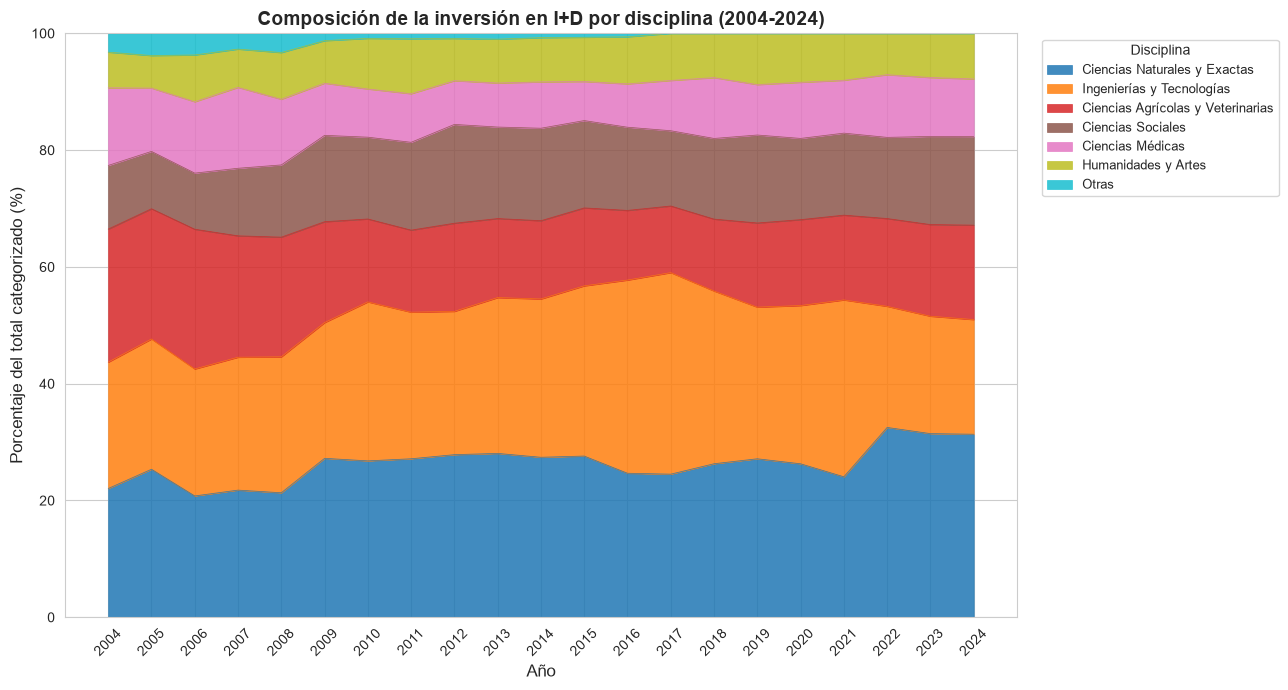

In [21]:
# ============================================================
# GRÁFICO 4: Evolución por disciplina
# ============================================================

# ------------------------------------------------------------
# Validaciones
# ------------------------------------------------------------

if df_disciplinas["DISCIPL_ID"].isna().any():
    cantidad = df_disciplinas["DISCIPL_ID"].isna().sum()
    raise ValueError(
        f"Existen {cantidad} registros sin disciplina."
    )

disciplinas_vacias = (
    df_disciplinas["DISCIPL_ID"]
    .astype("string")
    .str.strip()
    .eq("")
)

if disciplinas_vacias.any():
    cantidad = disciplinas_vacias.sum()
    raise ValueError(
        f"Existen {cantidad} registros con disciplina vacía."
    )


# ------------------------------------------------------------
# Validar duplicados del grano (ANIO, DISCIPL_ID)
# ------------------------------------------------------------

duplicados = df_disciplinas.duplicated(
    subset=["ANIO", "DISCIPL_ID"]
)

if duplicados.any():
    registros_duplicados = (
        df_disciplinas
        .loc[duplicados, ["ANIO", "DISCIPL_ID"]]
        .drop_duplicates()
        .values
        .tolist()
    )
    raise ValueError(
        "Existen registros duplicados para "
        f"(ANIO, DISCIPL_ID): {registros_duplicados}"
    )


# ------------------------------------------------------------
# Crear tabla de inversión por disciplina
# ------------------------------------------------------------

pivot_disc = (
    df_disciplinas
    .pivot(
        index="ANIO",
        columns="DISCIPL_ID",
        values="INV_ID_PESOS_CORR"
    )
    .fillna(0)
)


# ------------------------------------------------------------
# Validar totales anuales
# ------------------------------------------------------------

totales_disciplina = pivot_disc.sum(axis=1)

if (totales_disciplina <= 0).any():
    anios_invalidos = (
        totales_disciplina[totales_disciplina <= 0]
        .index
        .tolist()
    )
    raise ValueError(
        "Existen años con inversión categorizada "
        f"menor o igual a cero: {anios_invalidos}"
    )


# ------------------------------------------------------------
# Calcular participación porcentual
# ------------------------------------------------------------

pivot_disc_pct = (
    pivot_disc
    .div(totales_disciplina, axis=0)
    * 100
)


# ------------------------------------------------------------
# Verificar que cada año sume 100%
# ------------------------------------------------------------

suma_pct = pivot_disc_pct.sum(axis=1)

if not np.isclose(suma_pct, 100, atol=1e-10).all():
    raise ValueError(
        "La composición por disciplina "
        "no suma 100% en todos los años."
    )


# ------------------------------------------------------------
# Ordenar disciplinas por participación promedio
# ------------------------------------------------------------

orden_disciplinas = (
    pivot_disc_pct
    .mean()
    .sort_values(ascending=False)
    .index
)

pivot_disc_pct = pivot_disc_pct[orden_disciplinas]


# ------------------------------------------------------------
# Años inicial y final (como int de Python, no numpy)
# ------------------------------------------------------------

anio_inicial = int(pivot_disc_pct.index.min())
anio_final = int(pivot_disc_pct.index.max())


# ------------------------------------------------------------
# Comparación de participación relativa (en pp)
# ------------------------------------------------------------

comparacion_disc = pd.DataFrame({
    anio_inicial: pivot_disc_pct.loc[anio_inicial],
    anio_final: pivot_disc_pct.loc[anio_final]
})

comparacion_disc["CAMBIO_PP"] = (
    comparacion_disc[anio_final]
    - comparacion_disc[anio_inicial]
)

print(
    f"\nComposición por disciplina (relativa): "
    f"{anio_inicial} vs {anio_final}"
)

print(
    comparacion_disc
    .sort_values(by="CAMBIO_PP", ascending=False)
    .round(2)
)


# ------------------------------------------------------------
# Comparación de inversión absoluta (en pesos corrientes)
# ------------------------------------------------------------

comparacion_disc_abs = pd.DataFrame({
    anio_inicial: pivot_disc.loc[anio_inicial],
    anio_final: pivot_disc.loc[anio_final]
})

comparacion_disc_abs["CAMBIO_ABS"] = (
    comparacion_disc_abs[anio_final]
    - comparacion_disc_abs[anio_inicial]
)

comparacion_disc_abs["CAMBIO_ABS_PCT"] = (
    comparacion_disc_abs["CAMBIO_ABS"]
    / comparacion_disc_abs[anio_inicial].replace(0, pd.NA)
    * 100
)

print(
    f"\nInversión absoluta por disciplina "
    f"(pesos corrientes): "
    f"{anio_inicial} vs {anio_final}"
)

print(
    comparacion_disc_abs
    .sort_values(by="CAMBIO_ABS", ascending=False)
    .round(2)
)


# ------------------------------------------------------------
# Análisis específico de "Otras"
# ------------------------------------------------------------

if "Otras" in pivot_disc_pct.columns:
    print("\nEvolución de la categoría 'Otras':")
    print(pivot_disc_pct["Otras"].round(2))


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7))

pivot_disc_pct.plot(
    kind="area",
    stacked=True,
    ax=ax,
    colormap="tab10",
    alpha=0.85,
    linewidth=0.5
)

ax.set_title(
    f"Composición de la inversión en I+D por disciplina "
    f"({anio_inicial}-{anio_final})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Año", fontsize=12)

ax.set_ylabel(
    "Porcentaje del total categorizado (%)",
    fontsize=12
)

ax.set_ylim(0, 100)
ax.set_xticks(pivot_disc_pct.index)
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Disciplina",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

### Interpretación

> **Nota metodológica:** la hoja de Disciplinas **no reconstruye el total
> nacional** de inversión en I+D. Los porcentajes calculados corresponden
> al subconjunto de inversión **categorizado por disciplina** en cada año.
> Por lo tanto, estos valores permiten analizar cambios en la composición
> disciplinaria, pero **no deben interpretarse como participación de cada
> disciplina sobre el total nacional de I+D**.

**Composición por disciplina: 2004 vs 2024**

| Disciplina | 2004 | 2024 | Cambio (pp) |
|------------|------|------|-------------|
| Ciencias Naturales y Exactas | 22,05% | 31,34% | **+9,30** |
| Ciencias Sociales | 10,90% | 15,17% | **+4,27** |
| Humanidades y Artes | 6,11% | 7,81% | **+1,70** |
| Ingenierías y Tecnologías | 21,64% | 19,64% | −2,00 |
| Ciencias Médicas | 13,29% | 9,86% | −3,43 |
| Ciencias Agrícolas y Veterinarias | 22,79% | 16,17% | **−6,62** |
| Otras | 3,22% | 0,00% | −3,22 |

**Disciplinas que aumentaron su participación relativa**

- **Ciencias Naturales y Exactas** presentó el **mayor aumento en puntos porcentuales**, pasando de 22,05% a 31,34% (+9,30 pp).
- **Ciencias Sociales** aumentó de 10,90% a 15,17% (+4,27 pp).
- **Humanidades y Artes** pasó de 6,11% a 7,81% (+1,70 pp).

En conjunto, estas tres disciplinas incrementaron su peso relativo dentro de la inversión categorizada.

**Disciplinas que redujeron su participación relativa**

- **Ciencias Agrícolas y Veterinarias** presentó la **mayor reducción**, pasando de 22,79% a 16,17% (−6,62 pp).
- **Ciencias Médicas** disminuyó de 13,29% a 9,86% (−3,43 pp).
- **Ingenierías y Tecnologías** pasó de 21,64% a 19,64% (−2,00 pp).

Estos resultados describen cambios en el **peso relativo** de cada disciplina dentro del total categorizado. Una reducción de participación **no implica necesariamente** una reducción de inversión absoluta.

**Participación relativa vs. inversión absoluta**

La comparación entre ambas métricas muestra una diferencia importante.

**Las seis disciplinas principales** aumentaron su inversión absoluta entre 2004 y 2024 en pesos corrientes. Sin embargo, **tres de ellas** —Ciencias Agrícolas y Veterinarias, Ciencias Médicas e Ingenierías y Tecnologías— **redujeron su participación relativa**.

Esto significa que su inversión **aumentó en términos absolutos**, pero lo hizo **a un ritmo inferior** al crecimiento del total de inversión categorizada por disciplina.

**Ejemplo:** Ciencias Agrícolas y Veterinarias pasó de 276 a 243.418 pesos corrientes, aumentando su inversión absoluta, mientras que su participación dentro del total categorizado **disminuyó** de 22,79% a 16,17%.

Este contraste es importante porque **evita interpretar automáticamente una caída porcentual como una caída de la inversión**.

**Evolución de la categoría "Otras"**

La categoría **"Otras"** registra participación durante los primeros años de la serie, con valores entre aproximadamente 0,74% y 3,80% entre 2004 y 2016. **A partir de 2017, no aparecen registros clasificados bajo esta categoría.**

El dataset permite observar esta **discontinuidad**, pero **no permite determinar por sí solo su causa**. En particular, no es suficiente para afirmar que se produjo un **cambio metodológico** sin documentación adicional que lo confirme.

**Hallazgo principal**

Entre 2004 y 2024, la composición de la inversión en I+D categorizada por disciplina experimentó cambios relevantes.

- **Principal aumento:** Ciencias Naturales y Exactas (+9,30 pp), seguida por Ciencias Sociales (+4,27 pp) y Humanidades y Artes (+1,70 pp).
- **Principal reducción:** Ciencias Agrícolas y Veterinarias (−6,62 pp), seguida por Ciencias Médicas (−3,43 pp) e Ingenierías y Tecnologías (−2,00 pp).
- **Análisis de inversión absoluta:** las seis disciplinas principales incrementaron sus montos en pesos corrientes, lo que demuestra que la evolución de la **participación relativa** y la evolución de la **inversión absoluta** pueden seguir **direcciones diferentes**.

Los resultados describen la **composición disciplinaria** de la inversión ejecutada dentro del subconjunto categorizado y **no permiten determinar**, por sí solos, las causas institucionales, económicas, metodológicas o de política científica que explican estos cambios.

---
# 7. Heatmap de provincias por año

Visualización de la concentración territorial a lo largo del tiempo.

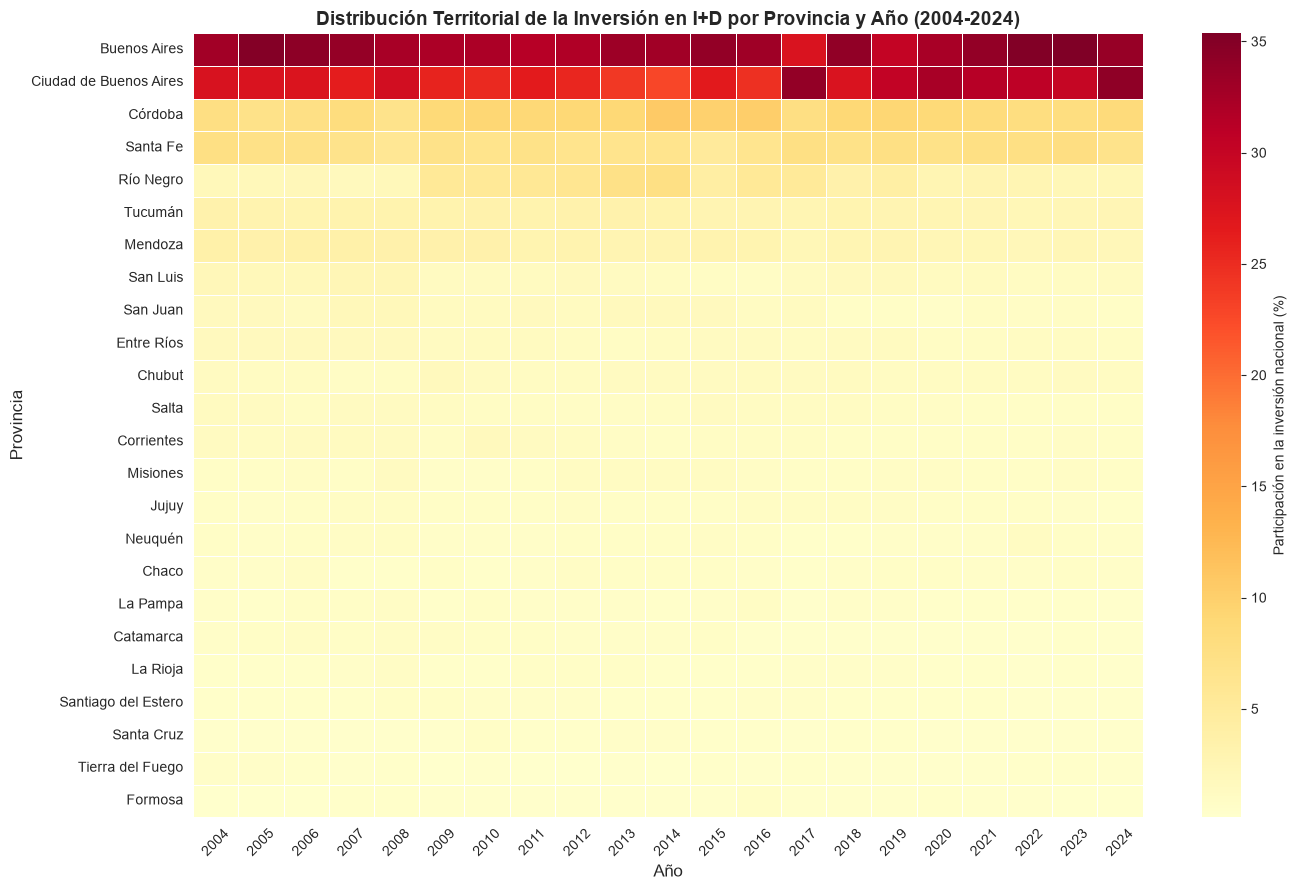

In [12]:
# ============================================================
# GRÁFICO 5: Heatmap de provincias
# ============================================================
pivot_prov = df_provincias.pivot_table(
    index='PROVINCIA', columns='ANIO',
    values='PROPORCION', aggfunc='sum'
).fillna(0)

# Ordenar por promedio histórico
pivot_prov = pivot_prov.loc[pivot_prov.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(pivot_prov, cmap='YlOrRd', annot=False,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Participación en la inversión nacional (%)'},
            ax=ax)

ax.set_title('Distribución Territorial de la Inversión en I+D por Provincia y Año (2004-2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Provincia', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

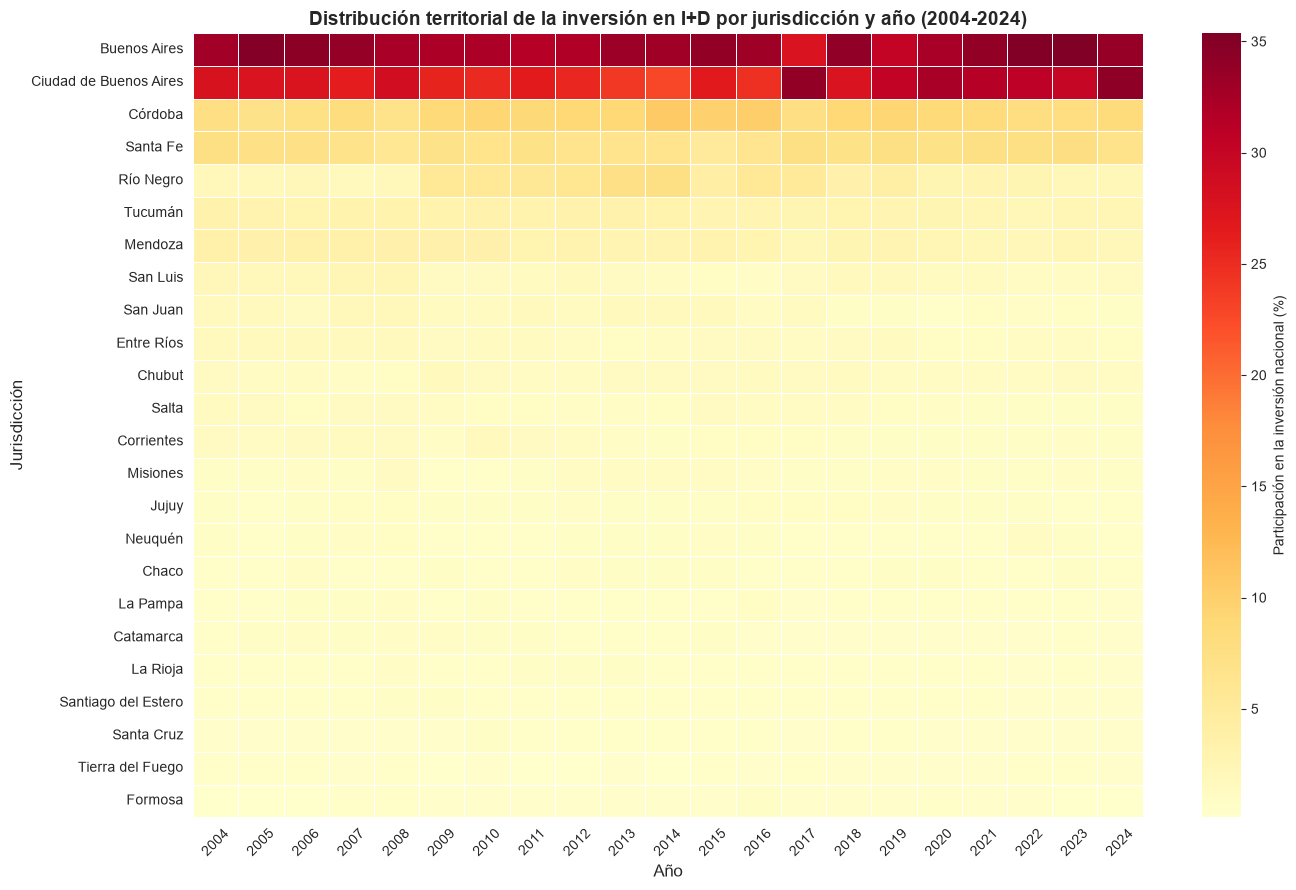


Jurisdicciones utilizadas para medir la concentración:
  - Buenos Aires
  - Ciudad de Buenos Aires

Concentración CABA + Buenos Aires por año:
ANIO
2004    60.69
2005    62.69
2006    61.87
2007    60.07
2008    60.93
2009    57.88
2010    57.35
2011    57.87
2012    57.30
2013    57.28
2014    55.76
2015    60.61
2016    57.71
2017    61.70
2018    61.72
2019    60.66
2020    64.76
2021    65.17
2022    65.88
2023    65.24
2024    67.83
dtype: float64

Concentración promedio: 61.00%
Año con mayor concentración: 2024 (67.83%)
Año con menor concentración: 2014 (55.76%)

Cambio interanual en la concentración (pp):
ANIO
2004     NaN
2005    2.00
2006   -0.83
2007   -1.79
2008    0.86
2009   -3.05
2010   -0.53
2011    0.52
2012   -0.56
2013   -0.02
2014   -1.52
2015    4.85
2016   -2.90
2017    3.99
2018    0.02
2019   -1.06
2020    4.10
2021    0.41
2022    0.70
2023   -0.63
2024    2.59
dtype: float64

Mayor salto positivo: 2015 (+4.85 pp)
Mayor salto negativo: 2009 (-3.05 pp)

Posición

In [23]:
# ============================================================
# GRÁFICO 5: Heatmap de evolución territorial
# ============================================================

# ------------------------------------------------------------
# Calcular PROPORCION (participación sobre el total nacional)
# ------------------------------------------------------------

total_por_anio = (
    df_provincias
    .groupby("ANIO")["INV_ID_PESOS_CORR"]
    .transform("sum")
)

df_provincias["PROPORCION"] = (
    df_provincias["INV_ID_PESOS_CORR"]
    / total_por_anio
    * 100
)


# ------------------------------------------------------------
# Validaciones
# ------------------------------------------------------------

if df_provincias["PROVINCIA"].isna().any():
    cantidad = df_provincias["PROVINCIA"].isna().sum()
    raise ValueError(
        f"Existen {cantidad} registros sin jurisdicción."
    )

jurisdicciones_vacias = (
    df_provincias["PROVINCIA"]
    .astype("string")
    .str.strip()
    .eq("")
)

if jurisdicciones_vacias.any():
    cantidad = jurisdicciones_vacias.sum()
    raise ValueError(
        f"Existen {cantidad} registros con jurisdicción vacía."
    )


# ------------------------------------------------------------
# Validar que PROPORCION exista
# ------------------------------------------------------------

if "PROPORCION" not in df_provincias.columns:
    raise ValueError(
        "La columna 'PROPORCION' no existe en df_provincias."
    )


# ------------------------------------------------------------
# Validar rango de proporciones
# ------------------------------------------------------------

proporciones = pd.to_numeric(
    df_provincias["PROPORCION"],
    errors="coerce"
)

if proporciones.isna().any():
    cantidad = proporciones.isna().sum()
    raise ValueError(
        f"Existen {cantidad} valores inválidos en PROPORCION."
    )

if (proporciones < 0).any():
    raise ValueError("PROPORCION contiene valores negativos.")

if (proporciones > 100).any():
    raise ValueError("PROPORCION contiene valores superiores al 100%.")


# ------------------------------------------------------------
# Validar grano (ANIO, PROVINCIA)
# ------------------------------------------------------------

duplicados = df_provincias.duplicated(
    subset=["ANIO", "PROVINCIA"]
)

if duplicados.any():
    registros_duplicados = (
        df_provincias
        .loc[duplicados, ["ANIO", "PROVINCIA"]]
        .drop_duplicates()
        .values
        .tolist()
    )
    raise ValueError(
        "Existen registros duplicados para "
        f"(ANIO, PROVINCIA): {registros_duplicados}"
    )


# ------------------------------------------------------------
# Crear matriz del heatmap
# ------------------------------------------------------------

pivot_prov = (
    df_provincias[["PROVINCIA", "ANIO", "PROPORCION"]]
    .pivot(
        index="PROVINCIA",
        columns="ANIO",
        values="PROPORCION"
    )
    .fillna(0)
)


# ------------------------------------------------------------
# Verificar cobertura temporal
# ------------------------------------------------------------

anios_esperados = sorted(df_provincias["ANIO"].unique())

anios_faltantes = [
    anio for anio in anios_esperados
    if anio not in pivot_prov.columns
]

if anios_faltantes:
    raise ValueError(
        f"Faltan años en el heatmap: {anios_faltantes}"
    )


# ------------------------------------------------------------
# Ordenar jurisdicciones por participación promedio
# ------------------------------------------------------------

orden_jurisdicciones = (
    pivot_prov
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

pivot_prov = pivot_prov.loc[orden_jurisdicciones]


# ------------------------------------------------------------
# Verificar que cada año sume 100%
# ------------------------------------------------------------

totales_participacion = pivot_prov.sum(axis=0)

if not np.isclose(
    totales_participacion, 100, atol=1e-10
).all():
    anios_invalidos = (
        totales_participacion[
            ~np.isclose(totales_participacion, 100, atol=1e-10)
        ]
        .index
        .tolist()
    )
    raise ValueError(
        "La participación jurisdiccional no suma 100% "
        f"en los siguientes años: {anios_invalidos}"
    )


# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    pivot_prov,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Participación en la inversión nacional (%)"
    },
    ax=ax
)

ax.set_title(
    "Distribución territorial de la inversión en I+D "
    f"por jurisdicción y año "
    f"({pivot_prov.columns.min()}-{pivot_prov.columns.max()})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Jurisdicción", fontsize=12)

ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Análisis complementario: concentración año a año
# ------------------------------------------------------------

# ------------------------------------------------------------
# Identificar CABA y Buenos Aires (reutilizar funciones)
# ------------------------------------------------------------

jurisdicciones_centro = [
    j for j in pivot_prov.index
    if es_caba(j) or es_buenos_aires(j)
]

if not jurisdicciones_centro:
    raise ValueError(
        "No se pudieron identificar CABA y/o Buenos Aires."
    )

print("\nJurisdicciones utilizadas para medir la concentración:")
for jurisdiccion in jurisdicciones_centro:
    print(f"  - {jurisdiccion}")


# ------------------------------------------------------------
# CABA + Buenos Aires año a año
# ------------------------------------------------------------

caba_ba_por_anio = (
    pivot_prov
    .loc[jurisdicciones_centro]
    .sum(axis=0)
)

print("\nConcentración CABA + Buenos Aires por año:")
print(caba_ba_por_anio.round(2))


# ------------------------------------------------------------
# Estadísticos principales
# ------------------------------------------------------------

concentracion_promedio = caba_ba_por_anio.mean()
anio_mayor_concentracion = caba_ba_por_anio.idxmax()
mayor_concentracion = caba_ba_por_anio.max()
anio_menor_concentracion = caba_ba_por_anio.idxmin()
menor_concentracion = caba_ba_por_anio.min()

print(f"\nConcentración promedio: {concentracion_promedio:.2f}%")
print(
    f"Año con mayor concentración: "
    f"{anio_mayor_concentracion} ({mayor_concentracion:.2f}%)"
)
print(
    f"Año con menor concentración: "
    f"{anio_menor_concentracion} ({menor_concentracion:.2f}%)"
)


# ------------------------------------------------------------
# Cambio año a año
# ------------------------------------------------------------

cambio_interanual_concentracion = caba_ba_por_anio.diff()

print("\nCambio interanual en la concentración (pp):")
print(cambio_interanual_concentracion.round(2))


# ------------------------------------------------------------
# Mayor incremento y mayor reducción
# ------------------------------------------------------------

cambio_interanual_valido = cambio_interanual_concentracion.dropna()

anio_mayor_salto_positivo = cambio_interanual_valido.idxmax()
mayor_salto_positivo = cambio_interanual_valido.max()

anio_mayor_salto_negativo = cambio_interanual_valido.idxmin()
mayor_salto_negativo = cambio_interanual_valido.min()

print(
    f"\nMayor salto positivo: "
    f"{anio_mayor_salto_positivo} ({mayor_salto_positivo:+.2f} pp)"
)
print(
    f"Mayor salto negativo: "
    f"{anio_mayor_salto_negativo} ({mayor_salto_negativo:+.2f} pp)"
)


# ------------------------------------------------------------
# Verificar liderazgo territorial año a año
# ------------------------------------------------------------

top_por_anio = (
    pivot_prov
    .rank(axis=0, method="min", ascending=False)
)

print("\nPosición de CABA y Buenos Aires año a año:")

for jurisdiccion in jurisdicciones_centro:
    print(f"\n{jurisdiccion}:")
    print(
        top_por_anio
        .loc[jurisdiccion]
        .astype(int)
        .to_string()
    )


# ------------------------------------------------------------
# Validación de ceros artificiales (fillna)
# ------------------------------------------------------------

combinaciones_totales = (
    df_provincias["PROVINCIA"].nunique()
    * df_provincias["ANIO"].nunique()
)

combinaciones_registradas = len(df_provincias)
combinaciones_faltantes = combinaciones_totales - combinaciones_registradas

print("\nValidación de cobertura del dataset:")
print(f"  Combinaciones jurisdicción-año totales: {combinaciones_totales}")
print(f"  Combinaciones con registro: {combinaciones_registradas}")
print(f"  Combinaciones faltantes: {combinaciones_faltantes}")

if combinaciones_faltantes > 0:
    porcentaje = combinaciones_faltantes / combinaciones_totales * 100
    print(
        f"  ⚠️ {porcentaje:.2f}% de combinaciones sin registro "
        f"(se interpretan como 0% en el heatmap)"
    )
else:
    print("  ✅ No hay combinaciones faltantes")

In [24]:
# Solo los prints finales (para ver sin truncamiento)
print("Año con mayor concentración:", caba_ba_por_anio.idxmax())
print("Valor máximo:", caba_ba_por_anio.max().round(2))

print("\nAño con menor concentración:", caba_ba_por_anio.idxmin())
print("Valor mínimo:", caba_ba_por_anio.min().round(2))

print("\nMayor salto positivo:", anio_mayor_salto_positivo)
print("Valor:", mayor_salto_positivo.round(2))

print("\nMayor salto negativo:", anio_mayor_salto_negativo)
print("Valor:", mayor_salto_negativo.round(2))

print("\nConcentración 2022:", caba_ba_por_anio.loc[2022].round(2))
print("Concentración 2023:", caba_ba_por_anio.loc[2023].round(2))
print("Concentración 2024:", caba_ba_por_anio.loc[2024].round(2))

Año con mayor concentración: 2024
Valor máximo: 67.83

Año con menor concentración: 2014
Valor mínimo: 55.76

Mayor salto positivo: 2015
Valor: 4.85

Mayor salto negativo: 2009
Valor: -3.05

Concentración 2022: 65.88
Concentración 2023: 65.24
Concentración 2024: 67.83


### Interpretación

> **Nota metodológica:** las participaciones representan el porcentaje
> de la inversión nacional en I+D **ejecutada** en cada jurisdicción.
> El heatmap muestra la evolución de esa participación para todas las
> jurisdicciones del dataset, ordenadas por participación promedio
> durante el período. Se utiliza la denominación "jurisdicciones"
> porque el dataset incluye tanto provincias como a la Ciudad Autónoma
> de Buenos Aires (CABA).
>
> **Nota sobre cobertura:** el dataset contiene registros para las
> **504 combinaciones jurisdicción-año** esperadas (24 jurisdicciones ×
> 21 años). **No se identificaron combinaciones faltantes**, por lo que
> el `fillna(0)` utilizado para construir el heatmap no introduce ceros
> artificiales por ausencia de registros.

**1. Persistencia del liderazgo territorial**

La verificación del **ranking anual** (calculado explícitamente en el
código, no por inspección visual) muestra que **Buenos Aires** y
**Ciudad de Buenos Aires** ocupan las **dos primeras posiciones durante
todo el período analizado**.

Esto indica que la concentración territorial observada en el Gráfico 3
no se limita a la comparación entre 2004 y 2024, sino que **se mantiene
a lo largo de toda la serie 2004–2024**.

**2. Evolución de la concentración CABA + Buenos Aires**

La participación conjunta de CABA y Buenos Aires presenta una
**evolución no lineal** durante el período:

| Año | Concentración |
|-----|---------------|
| 2004 | 60,69% |
| **2014** | **55,76%** (mínimo de la serie) |
| 2015 | 60,61% |
| **2024** | **67,83%** (máximo de la serie) |

- **Concentración promedio del período:** **61,00%**.

**Fases diferenciadas:**

- **2004–2014:** descenso gradual desde 60,69% hasta el mínimo de **55,76% en 2014**.
- **2014–2015:** incremento abrupto de **+4,85 pp**, el **mayor salto positivo de la serie**.
- **2015–2024:** **tendencia general ascendente, aunque con fluctuaciones interanuales**, hasta alcanzar el máximo de **67,83% en 2024**.

**3. Variaciones interanuales**

Los principales cambios interanuales identificados fueron:

- **Mayor incremento:** 2015, con **+4,85 pp**.
- **Mayor reducción:** 2009, con **−3,05 pp**.
- **Menor concentración:** 2014, con **55,76%**.
- **Mayor concentración:** 2024, con **67,83%**.

En los últimos tres años de la serie, la concentración conjunta fue:

| Año | Concentración |
|-----|---------------|
| 2022 | 65,88% |
| 2023 | 65,24% |
| 2024 | 67,83% |

Entre 2023 y 2024 se observa un incremento de **2,59 pp**.

**4. Relación con el análisis del Gráfico 3**

El heatmap **complementa** el análisis del Gráfico 3:

- La comparación **2004–2024** había mostrado que la participación conjunta de CABA + Buenos Aires pasó de **60,69% a 67,83%**, un incremento de **+7,13 pp**.
- El análisis **año a año** permite observar que este cambio **no ocurrió de manera uniforme**: la concentración primero **disminuyó** hasta un mínimo en 2014, para posteriormente **aumentar** hasta el máximo en 2024.

De esta manera, el heatmap permite distinguir entre el **resultado de los extremos del período** y la **trayectoria seguida entre ambos puntos**.

**Hallazgo principal**

Durante 2004–2024, **Buenos Aires y Ciudad de Buenos Aires mantuvieron
las dos primeras posiciones** en la distribución territorial de la
inversión en I+D del dataset.

La participación conjunta de ambas jurisdicciones pasó de **60,69% en
2004 a 67,83% en 2024**, con un **promedio del período de 61,00%**.
La trayectoria presentó variaciones importantes:

- **Mínimo de 55,76%** en 2014.
- **Mayor incremento interanual** en 2015 (+4,85 pp).
- **Máximo de 67,83%** en 2024.

Estos resultados describen la **distribución territorial** de la
inversión ejecutada. Por sí solos, **no permiten determinar** los
factores institucionales, económicos, metodológicos o de política
científica que explican las variaciones observadas.

# 8. Conclusiones

## Diagnóstico descriptivo del sistema de I+D argentino (2004–2024)

El análisis desarrollado permite caracterizar la evolución de la inversión en I+D en Argentina desde cuatro dimensiones principales: esfuerzo relativo sobre el PBI, sector de ejecución, distribución territorial y composición disciplinaria.

Los resultados deben interpretarse como un **diagnóstico descriptivo** del comportamiento observado en el dataset, **sin establecer relaciones causales**.

### Hallazgos principales

**1. Esfuerzo en I+D (% del PBI)**

* La inversión en I+D **no superó el 0,65% del PBI** durante el período 2004–2024.
* El máximo de la serie se registró en **2012**, con **0,63% del PBI**.
* En **2014** se registró un valor de **0,49% del PBI**.
* La trayectoria **no muestra un crecimiento sostenido** de la participación de la I+D sobre el PBI durante todo el período.
* En **2024**, la participación descendió a **0,49%**, frente al **0,59%** registrado en 2023.

**2. Composición por sector de ejecución**

La estructura sectorial presenta una participación predominante de los sectores públicos, aunque con cambios en su composición:

* **Universidades públicas y organismos públicos de ciencia y tecnología** representaban conjuntamente **72,8% en 2004** y **71,0% en 2024**.
* **Empresas:** aumentaron su participación de **15,2% a 26,0%**, equivalente a **+10,8 puntos porcentuales**.
* **Universidades privadas y entidades sin fines de lucro:** redujeron su participación relativa durante el período.

Por lo tanto, el principal cambio observado en la composición sectorial fue el **aumento de la participación de las empresas**, mientras que los **sectores públicos continuaron representando aproximadamente siete de cada diez puntos porcentuales de la inversión ejecutada**.

> **Importante:** estos porcentajes corresponden al **sector de ejecución**, no necesariamente a la **fuente que financió** la inversión.

**3. Distribución territorial**

La inversión en I+D presenta una **concentración significativa** en determinadas jurisdicciones:

* **Buenos Aires + Ciudad de Buenos Aires** representaron conjuntamente entre **55,76% y 67,83%** de la inversión ejecutada durante el período.
* El **promedio** de su participación conjunta entre 2004 y 2024 fue de aproximadamente **61,00%**.
* La concentración alcanzó su **mínimo en 2014**, con **55,76%**.
* En **2024** alcanzó el **máximo de la serie**, con **67,83%**.
* **Buenos Aires y Ciudad de Buenos Aires ocuparon las dos primeras posiciones** del ranking territorial en cada año analizado.

La trayectoria **no fue lineal**: la concentración disminuyó entre 2004 y 2014 y posteriormente presentó una **tendencia general ascendente, con fluctuaciones interanuales**.

**4. Composición por disciplina**

La composición de la inversión **categorizada por disciplina** también presentó modificaciones importantes:

| Disciplina                        | Cambio (pp) |
| --------------------------------- | ----------: |
| Ciencias Naturales y Exactas      |   **+9,30** |
| Ciencias Sociales                 |   **+4,27** |
| Humanidades y Artes               |   **+1,70** |
| Ingenierías y Tecnologías         |       −2,00 |
| Ciencias Médicas                  |       −3,43 |
| Ciencias Agrícolas y Veterinarias |   **−6,62** |

Las principales disciplinas aumentaron su inversión absoluta **en pesos corrientes** entre 2004 y 2024. Sin embargo, algunas **redujeron su participación relativa** porque el total de inversión categorizada creció a un ritmo superior.

Este resultado demuestra la importancia de **distinguir entre variación absoluta y participación relativa** al interpretar la evolución de la inversión.

**5. Situación de 2024**

El año 2024 presenta una **reducción respecto del año anterior**:

* La inversión expresada en **USD PPC disminuyó aproximadamente 17%** respecto de 2023.
* La **participación sobre el PBI** pasó de **0,59% en 2023** a **0,49% en 2024**.
* Al mismo tiempo, la **concentración territorial** de Buenos Aires + CABA alcanzó **67,83%**, el máximo observado en la serie.

Estos resultados permiten **caracterizar el comportamiento de 2024**, pero **no permiten atribuir las variaciones observadas** a factores económicos, institucionales o de política científica sin incorporar información adicional.

### Limitaciones metodológicas

**1. Ejecución vs. financiamiento**

El dataset analiza la inversión según **sector de ejecución**. Esto **no equivale necesariamente** a identificar quién financia la investigación. La distinción entre **ejecutor** y **fuente de financiamiento** es fundamental para interpretar correctamente la estructura del sistema de I+D.

**2. Subconjunto categorizado por disciplina**

La hoja de Disciplinas **no reconstruye el total nacional** de inversión en I+D. Los porcentajes calculados representan la composición del **subconjunto categorizado** por disciplina. Por lo tanto, sus resultados deben interpretarse como **cambios en la composición disciplinaria de dicho subconjunto**, y no como participación de cada disciplina sobre el total nacional.

**3. Inflación y unidades monetarias**

Los valores expresados en **pesos corrientes no son directamente comparables entre años**, debido al efecto de la inflación.

Por esta razón, las comparaciones temporales de magnitud monetaria se realizaron utilizando la serie expresada en **USD PPC**, mientras que los valores en pesos corrientes se utilizaron principalmente para contrastar magnitudes **dentro de un mismo año** y para complementar el análisis.

**4. Categoría "Otras" en disciplinas**

La categoría **"Otras"** presenta registros durante los primeros años de la serie, pero **deja de aparecer a partir de 2017**.

El dataset permite identificar esta **discontinuidad**, pero **no permite determinar por sí solo su causa**. No se debe interpretar automáticamente como un **cambio metodológico** sin documentación adicional que lo confirme.

**5. Alcance descriptivo del análisis**

El análisis identifica **patrones, variaciones y relaciones descriptivas** dentro de los datos. **No permite establecer**, por sí solo, **relaciones causales** ni determinar si los cambios observados fueron provocados por determinadas políticas públicas, condiciones económicas, decisiones institucionales u otros factores.

### Próximos pasos

El notebook desarrollado constituye una **primera capa de análisis descriptivo** y deja preparada una estructura para investigaciones posteriores.

**Las principales líneas de trabajo futuro son:**

1. **Incorporar información sobre fuentes de financiamiento**, permitiendo distinguir **quién financia** la I+D de **quién la ejecuta**.
2. **Realizar comparaciones internacionales** con países de la OCDE utilizando indicadores, unidades y períodos homogéneos.
3. **Incorporar análisis estadístico más avanzado** para estudiar tendencias, cambios de nivel, quiebres estructurales y relaciones entre variables, cuando la disponibilidad y calidad de los datos lo permitan.
4. **Integrar datasets adicionales** sobre patentes, publicaciones científicas, recursos humanos en I+D y resultados de investigación, para construir un análisis multidimensional del sistema científico-tecnológico.
5. **Incorporar variables macroeconómicas relevantes** para estudiar asociaciones entre la evolución de la inversión en I+D y el contexto económico, manteniendo la distinción entre asociación estadística y causalidad.

### Conclusión general

Entre 2004 y 2024, la inversión en I+D en Argentina presentó **variaciones importantes** en su magnitud, composición sectorial, distribución territorial y composición disciplinaria, **sin mostrar una trayectoria uniforme** en todas estas dimensiones.

* La **participación de la I+D sobre el PBI** permaneció por debajo del **0,65%** durante todo el período.
* En términos sectoriales, los **ejecutores públicos mantuvieron una participación predominante**, mientras que **las empresas incrementaron su peso relativo**.
* Territorialmente, **Buenos Aires y Ciudad de Buenos Aires concentraron conjuntamente alrededor del 61% de la inversión en promedio**, alcanzando el **67,83% en 2024**.
* En cuanto a disciplinas, se observaron **cambios relevantes en la composición relativa**, particularmente el **aumento de Ciencias Naturales y Exactas** y la **reducción de la participación relativa de Ciencias Agrícolas y Veterinarias**.

En conjunto, estos resultados proporcionan una **caracterización cuantitativa** de la evolución del sistema de I+D argentino a partir de las dimensiones disponibles en el dataset. **Las explicaciones de los patrones identificados requieren incorporar fuentes adicionales y análisis específicos** que permitan pasar de un **diagnóstico descriptivo** a un **análisis explicativo**.
